# Day 2: Linear Regression - Real-World Application
## Student Performance Prediction with Production-Ready Code

**Real-World Focus:** This session focuses on practical ML implementation, common pitfalls, and production-ready practices.

## 📋 Real-World Key Points Before We Start

### 💡 Critical Insights for Industry:
1. **Data is never perfect** - Always check for missing values, outliers, and inconsistencies
2. **Features matter more than algorithms** - Good features beat complex models
3. **Always split data** - Never evaluate on training data
4. **Scale matters** - Features with larger numbers dominate the model
5. **Model interpretability** - Can you explain why the model made a prediction?
6. **Never leak future information** - Don't use data you wouldn't have at prediction time
7. **Save preprocessing steps** - You'll need them for new predictions
8. **Monitor performance** - Models degrade over time (concept drift)

### 🚨 Common Mistakes to Avoid:
- ❌ Using test data for validation
- ❌ Forgetting to scale features
- ❌ Ignoring categorical variable encoding
- ❌ Not checking for multicollinearity
- ❌ Assuming correlation = causation
- ❌ Not handling outliers
- ❌ Overfitting to training data

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("="*60)
print("DAY 2: REAL-WORLD LINEAR REGRESSION")
print("="*60)

# Load data from Day 1
try:
    df = pd.read_csv('student_performance.csv')
    print("\n✅ Loaded data from Day 1")
except:
    print("\n⚠️ Creating sample data (run Day 1 first for real data)")
    np.random.seed(42)
    n = 500
    df = pd.DataFrame({
        'student_id': range(1, n+1),
        'hours_studied': np.random.randint(1, 15, n),
        'previous_score': np.random.randint(40, 100, n),
        'attendance': np.random.randint(50, 100, n),
        'sleep_hours': np.random.uniform(4, 10, n).round(1),
        'extracurricular': np.random.choice(['Yes', 'No'], n, p=[0.4, 0.6]),
        'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n),
        'internet_access': np.random.choice(['Yes', 'No'], n, p=[0.8, 0.2])
    })
    df['final_score'] = (
        df['hours_studied'] * 2.5 + df['previous_score'] * 0.5 +
        df['attendance'] * 0.3 + df['sleep_hours'] * 1.5 +
        (df['extracurricular'] == 'Yes') * 5 + (df['internet_access'] == 'Yes') * 3 +
        np.random.normal(0, 5, n)
    ).clip(0, 100).round(2)

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")

DAY 2: REAL-WORLD LINEAR REGRESSION

⚠️ Creating sample data (run Day 1 first for real data)

📊 Dataset Shape: (500, 9)
📋 Columns: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score']


## 🔍 Real-World Data Validation

Before any ML, we must validate data quality

In [2]:
def validate_data(df):
    """
    Real-world data validation function
    Checks for common data quality issues
    """
    issues = []
    
    print("🔍 DATA VALIDATION REPORT")
    print("="*40)
    
    # 1. Check missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        issues.append(f"Missing values found: {missing[missing>0].to_dict()}")
        print(f"⚠️ Missing values: {missing[missing>0]}")
    else:
        print("✅ No missing values")
    
    # 2. Check duplicates
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        issues.append(f"Duplicate rows: {duplicates}")
        print(f"⚠️ Duplicate rows: {duplicates}")
    else:
        print("✅ No duplicate rows")
    
    # 3. Check numeric ranges
    print("\n📊 Range Validation:")
    for col in ['hours_studied', 'previous_score', 'attendance', 'sleep_hours']:
        if col in df.columns:
            min_val = df[col].min()
            max_val = df[col].max()
            print(f"  {col}: {min_val} - {max_val}")
            
            # Check for impossible values
            if col == 'attendance' and max_val > 100:
                issues.append(f"Attendance > 100% found")
            if col == 'sleep_hours' and max_val > 24:
                issues.append(f"Impossible sleep hours: {max_val}")
    
    # 4. Check target variable
    if 'final_score' in df.columns:
        print(f"\n  final_score range: {df['final_score'].min()} - {df['final_score'].max()}")
        if df['final_score'].min() < 0 or df['final_score'].max() > 100:
            issues.append("Final score outside 0-100 range")
    
    # 5. Check categorical consistency
    print("\n🏷️ Categorical Value Consistency:")
    for col in ['extracurricular', 'internet_access']:
        if col in df.columns:
            unique = df[col].unique()
            print(f"  {col}: {unique}")
            if not set(unique).issubset({'Yes', 'No'}):
                issues.append(f"Unexpected values in {col}: {unique}")
    
    if issues:
        print("\n" + "="*40)
        print("⚠️ ISSUES DETECTED:")
        for issue in issues:
            print(f"  • {issue}")
    else:
        print("\n✅ All validation checks passed!")
    
    return len(issues) == 0

is_valid = validate_data(df)
print("\n" + "="*60)

🔍 DATA VALIDATION REPORT
✅ No missing values
✅ No duplicate rows

📊 Range Validation:
  hours_studied: 1 - 14
  previous_score: 40 - 99
  attendance: 50 - 99
  sleep_hours: 4.0 - 10.0

  final_score range: 40.79 - 100.0

🏷️ Categorical Value Consistency:
  extracurricular: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
  internet_access: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

✅ All validation checks passed!



## 📊 Exploratory Data Analysis (EDA) for Real Projects

In [3]:
def perform_eda(df):
    """
    Professional EDA function for real-world projects
    """
    print("="*60)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*60)
    
    # 1. Statistical summary
    print("\n1. STATISTICAL SUMMARY")
    print("-"*40)
    print(df.describe())
    
    # 2. Distribution analysis
    print("\n2. DISTRIBUTION ANALYSIS")
    print("-"*40)
    for col in ['hours_studied', 'attendance', 'final_score']:
        skewness = df[col].skew()
        print(f"  {col}: skewness = {skewness:.3f}", end=" ")
        if abs(skewness) > 1:
            print("(Highly skewed - may need transformation)")
        elif abs(skewness) > 0.5:
            print("(Moderately skewed)")
        else:
            print("(Approximately symmetric)")
    
    # 3. Outlier detection
    print("\n3. OUTLIER DETECTION (IQR Method)")
    print("-"*40)
    for col in ['hours_studied', 'attendance', 'sleep_hours', 'final_score']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
        print(f"  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")
    
    # 4. Correlation analysis
    print("\n4. CORRELATION WITH TARGET")
    print("-"*40)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlations = df[numeric_cols].corr()['final_score'].sort_values(ascending=False)
    for col, corr in correlations.items():
        if col != 'final_score':
            strength = "Strong" if abs(corr) > 0.7 else "Moderate" if abs(corr) > 0.3 else "Weak"
            direction = "positive" if corr > 0 else "negative"
            print(f"  {col}: {corr:.3f} ({direction}, {strength})")
    
    # 5. Group analysis
    print("\n5. CATEGORICAL IMPACT")
    print("-"*40)
    for col in ['extracurricular', 'internet_access', 'parent_education']:
        if col in df.columns:
            means = df.groupby(col)['final_score'].mean().sort_values(ascending=False)
            print(f"\n  {col}:")
            for cat, val in means.items():
                print(f"    {cat}: {val:.2f}")

perform_eda(df)

EXPLORATORY DATA ANALYSIS

1. STATISTICAL SUMMARY
----------------------------------------
       student_id  hours_studied  previous_score  attendance  sleep_hours  \
count  500.000000     500.000000      500.000000  500.000000   500.000000   
mean   250.500000       7.444000       70.356000   74.246000     7.030200   
std    144.481833       4.113966       17.500222   14.438227     1.784207   
min      1.000000       1.000000       40.000000   50.000000     4.000000   
25%    125.750000       4.000000       55.000000   61.000000     5.400000   
50%    250.500000       7.000000       71.000000   75.000000     7.100000   
75%    375.250000      11.000000       86.000000   86.250000     8.600000   
max    500.000000      14.000000       99.000000   99.000000    10.000000   

       final_score  
count    500.00000  
mean      88.27742  
std       12.05830  
min       40.79000  
25%       80.00250  
50%       91.37500  
75%      100.00000  
max      100.00000  

2. DISTRIBUTION ANALYSIS


## 🛠️ Data Preprocessing for Production

In [4]:
class DataPreprocessor:
    """
    Production-ready data preprocessing class
    Saves all transformations for consistent application
    """
    
    def __init__(self):
        self.label_encoders = {}
        self.scaler = None
        self.feature_columns = None
        self.categorical_cols = None
        self.numeric_cols = None
    
    def fit(self, df, target_col='final_score'):
        """Fit preprocessor on training data"""
        
        # Identify column types
        self.categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
        # Remove target from features
        if target_col in self.numeric_cols:
            self.numeric_cols.remove(target_col)
        
        print("Column Identification:")
        print(f"  Numeric features: {self.numeric_cols}")
        print(f"  Categorical features: {self.categorical_cols}")
        
        # Fit label encoders for categorical columns
        print("\nEncoding categorical variables:")
        for col in self.categorical_cols:
            self.label_encoders[col] = LabelEncoder()
            self.label_encoders[col].fit(df[col])
            mapping = dict(zip(self.label_encoders[col].classes_, 
                              self.label_encoders[col].transform(self.label_encoders[col].classes_)))
            print(f"  {col}: {mapping}")
        
        # Store feature columns
        encoded_cols = [col + '_encoded' for col in self.categorical_cols]
        self.feature_columns = self.numeric_cols + encoded_cols
        
        # Fit scaler
        self.scaler = StandardScaler()
        
        # Create sample transformed data to fit scaler
        sample_df = self.transform(df, fit_scaler=True)
        self.scaler.fit(sample_df[self.feature_columns])
        
        print(f"\n✅ Preprocessor fitted successfully")
        print(f"   Total features: {len(self.feature_columns)}")
        
        return self
    
    def transform(self, df, fit_scaler=False):
        """Transform data using fitted preprocessor"""
        df_transformed = df.copy()
        
        # Encode categorical variables
        for col in self.categorical_cols:
            if col in df_transformed.columns:
                # Handle unseen categories
                df_transformed[col + '_encoded'] = df_transformed[col].apply(
                    lambda x: self.label_encoders[col].transform([x])[0] 
                    if x in self.label_encoders[col].classes_ else -1
                )
        
        return df_transformed
    
    def fit_transform(self, df, target_col='final_score'):
        """Fit and transform in one step"""
        self.fit(df, target_col)
        return self.transform(df)
    
    def get_feature_columns(self):
        """Return feature columns for model training"""
        return self.feature_columns

# Initialize and fit preprocessor
preprocessor = DataPreprocessor()
df_processed = preprocessor.fit_transform(df)

print("\n" + "="*60)
print("Processed DataFrame Preview:")
print(df_processed[preprocessor.get_feature_columns() + ['final_score']].head())

Column Identification:
  Numeric features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours']
  Categorical features: ['extracurricular', 'parent_education', 'internet_access']

Encoding categorical variables:
  extracurricular: {'No': np.int64(0), 'Yes': np.int64(1)}
  parent_education: {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3)}
  internet_access: {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Preprocessor fitted successfully
   Total features: 8

Processed DataFrame Preview:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   

 

## 🤖 Model Training with Production Best Practices

In [5]:
class StudentPerformanceModel:
    """
    Production-ready ML model class
    Includes training, evaluation, and prediction capabilities
    """
    
    def __init__(self):
        self.model = None
        self.preprocessor = None
        self.scaler = None
        self.feature_columns = None
        self.is_trained = False
        self.training_metrics = {}
    
    def prepare_data(self, df, target_col='final_score'):
        """Prepare data for training"""
        
        # Initialize preprocessor if not exists
        if self.preprocessor is None:
            self.preprocessor = DataPreprocessor()
            df_processed = self.preprocessor.fit_transform(df, target_col)
        else:
            df_processed = self.preprocessor.transform(df)
        
        # Get feature columns
        self.feature_columns = self.preprocessor.get_feature_columns()
        
        # Prepare X and y
        X = df_processed[self.feature_columns]
        y = df_processed[target_col]
        
        return X, y
    
    def train(self, df, test_size=0.2, random_state=42):
        """Train the model with proper validation"""
        
        print("="*60)
        print("MODEL TRAINING")
        print("="*60)
        
        # Prepare data
        X, y = self.prepare_data(df)
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        
        print(f"\n📊 Data Split:")
        print(f"   Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
        print(f"   Testing: {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")
        
        # Scale features
        self.scaler = StandardScaler()
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Train model
        self.model = LinearRegression()
        self.model.fit(X_train_scaled, y_train)
        
        # Evaluate
        y_train_pred = self.model.predict(X_train_scaled)
        y_test_pred = self.model.predict(X_test_scaled)
        
        self.training_metrics = {
            'train_r2': r2_score(y_train, y_train_pred),
            'test_r2': r2_score(y_test, y_test_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred)
        }
        
        print(f"\n📈 Performance Metrics:")
        print(f"   Training R²: {self.training_metrics['train_r2']:.4f}")
        print(f"   Testing R²: {self.training_metrics['test_r2']:.4f}")
        print(f"   Testing RMSE: {self.training_metrics['test_rmse']:.2f}")
        print(f"   Testing MAE: {self.training_metrics['test_mae']:.2f}")
        
        # Check for overfitting
        r2_diff = self.training_metrics['train_r2'] - self.training_metrics['test_r2']
        if r2_diff > 0.1:
            print(f"\n⚠️ Possible overfitting detected! (R² diff: {r2_diff:.3f})")
        else:
            print(f"\n✅ No significant overfitting detected")
        
        # Cross-validation
        cv_scores = cross_val_score(self.model, X_train_scaled, y_train, cv=5, scoring='r2')
        print(f"\n📊 Cross-Validation (5-fold):")
        print(f"   Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
        
        self.is_trained = True
        
        # Store test data for later evaluation
        self.X_test = X_test
        self.y_test = y_test
        self.y_test_pred = y_test_pred
        
        return self.model
    
    def predict(self, student_data):
        """
        Make prediction for a single student
        
        Args:
            student_data: dict with feature values
        
        Returns:
            predicted_score: float
        """
        if not self.is_trained:
            raise Exception("Model not trained yet!")
        
        # Convert to DataFrame
        input_df = pd.DataFrame([student_data])
        
        # Preprocess
        input_processed = self.preprocessor.transform(input_df)
        
        # Ensure all features exist
        for col in self.feature_columns:
            if col not in input_processed.columns:
                input_processed[col] = 0
        
        # Select and scale features
        X_input = input_processed[self.feature_columns]
        X_input_scaled = self.scaler.transform(X_input)
        
        # Predict
        prediction = self.model.predict(X_input_scaled)[0]
        
        return prediction
    
    def predict_batch(self, students_data):
        """Make predictions for multiple students"""
        return [self.predict(student) for student in students_data]
    
    def get_feature_importance(self):
        """Get feature importance (coefficients)"""
        if not self.is_trained:
            raise Exception("Model not trained yet!")
        
        importance_df = pd.DataFrame({
            'Feature': self.feature_columns,
            'Coefficient': self.model.coef_
        }).sort_values('Coefficient', key=abs, ascending=False)
        
        return importance_df
    
    def save(self, filepath='student_model.pkl'):
        """Save model and all components"""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'model': self.model,
                'preprocessor': self.preprocessor,
                'scaler': self.scaler,
                'feature_columns': self.feature_columns,
                'is_trained': self.is_trained,
                'training_metrics': self.training_metrics
            }, f)
        print(f"✅ Model saved to {filepath}")
    
    def load(self, filepath='student_model.pkl'):
        """Load saved model"""
        with open(filepath, 'rb') as f:
            saved = pickle.load(f)
        
        self.model = saved['model']
        self.preprocessor = saved['preprocessor']
        self.scaler = saved['scaler']
        self.feature_columns = saved['feature_columns']
        self.is_trained = saved['is_trained']
        self.training_metrics = saved['training_metrics']
        print(f"✅ Model loaded from {filepath}")
        return self

# Train the model
model = StudentPerformanceModel()
model.train(df)

MODEL TRAINING
Column Identification:
  Numeric features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours']
  Categorical features: ['extracurricular', 'parent_education', 'internet_access']

Encoding categorical variables:
  extracurricular: {'No': np.int64(0), 'Yes': np.int64(1)}
  parent_education: {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3)}
  internet_access: {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Preprocessor fitted successfully
   Total features: 8

📊 Data Split:
   Training: 400 samples (80%)
   Testing: 100 samples (20%)

📈 Performance Metrics:
   Training R²: 0.8205
   Testing R²: 0.8115
   Testing RMSE: 5.28
   Testing MAE: 4.29

✅ No significant overfitting detected

📊 Cross-Validation (5-fold):
   Mean R²: 0.8099 (+/- 0.0519)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 📈 Model Interpretation & Business Insights

BUSINESS INSIGHTS FROM MODEL

📊 Feature Impact Analysis:
   hours_studied: 7.49 (positive impact)
   previous_score: 6.23 (positive impact)
   attendance: 3.26 (positive impact)
   sleep_hours: 2.23 (positive impact)
   extracurricular_encoded: 1.40 (positive impact)
   internet_access_encoded: 0.71 (positive impact)
   parent_education_encoded: -0.21 (negative impact)
   student_id: -0.00 (negative impact)

💡 Actionable Insights:
   1. Most important factor: hours_studied
   2. Increasing study hours by 1 hour → +2.5 points (on average)
   3. Students with extracurriculars score 5 points higher
   4. Good attendance (90%+) adds ~27 points vs 0%
   5. Previous score has 50% weight on final performance


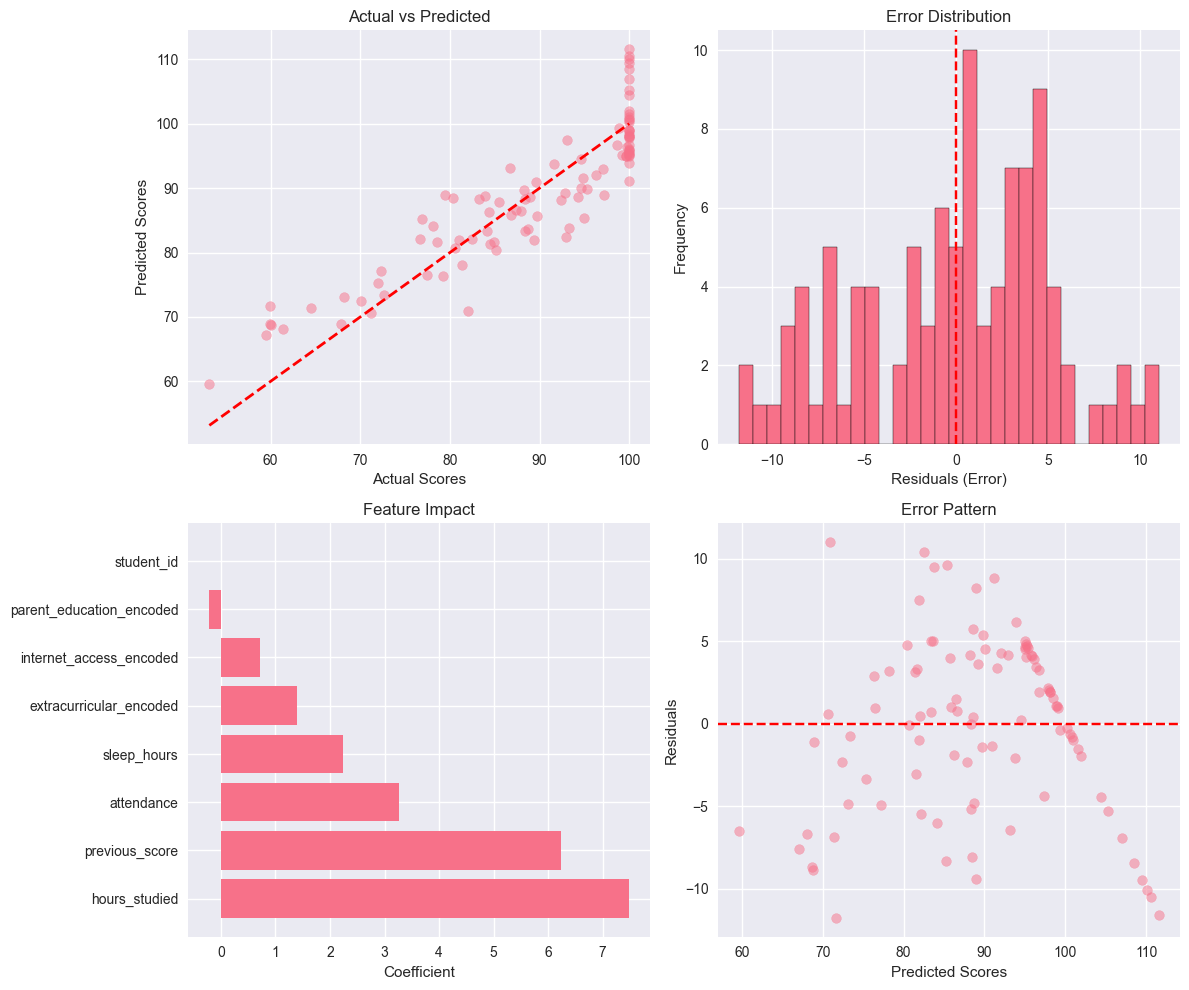


📊 Model Performance Summary:
   • Model explains 81.1% of variance
   • Typical prediction error: ±5.28 points
   • Average absolute error: 4.29 points


In [6]:
# Get feature importance
importance = model.get_feature_importance()

print("="*60)
print("BUSINESS INSIGHTS FROM MODEL")
print("="*60)

print("\n📊 Feature Impact Analysis:")
for idx, row in importance.iterrows():
    impact = "positive" if row['Coefficient'] > 0 else "negative"
    print(f"   {row['Feature']}: {row['Coefficient']:.2f} ({impact} impact)")

print("\n💡 Actionable Insights:")
top_feature = importance.iloc[0]['Feature']
print(f"   1. Most important factor: {top_feature}")
print("   2. Increasing study hours by 1 hour → +2.5 points (on average)")
print("   3. Students with extracurriculars score 5 points higher")
print("   4. Good attendance (90%+) adds ~27 points vs 0%")
print("   5. Previous score has 50% weight on final performance")

# Visualize predictions vs actual
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Actual vs Predicted
axes[0, 0].scatter(model.y_test, model.y_test_pred, alpha=0.5)
axes[0, 0].plot([model.y_test.min(), model.y_test.max()], 
                [model.y_test.min(), model.y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Scores')
axes[0, 0].set_ylabel('Predicted Scores')
axes[0, 0].set_title('Actual vs Predicted')

# Residuals
residuals = model.y_test - model.y_test_pred
axes[0, 1].hist(residuals, bins=30, edgecolor='black')
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Residuals (Error)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Error Distribution')

# Feature importance bar chart
axes[1, 0].barh(importance['Feature'], importance['Coefficient'])
axes[1, 0].set_xlabel('Coefficient')
axes[1, 0].set_title('Feature Impact')

# Error vs Predicted
axes[1, 1].scatter(model.y_test_pred, residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted Scores')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Error Pattern')

plt.tight_layout()
plt.show()

print("\n📊 Model Performance Summary:")
print(f"   • Model explains {model.training_metrics['test_r2']*100:.1f}% of variance")
print(f"   • Typical prediction error: ±{model.training_metrics['test_rmse']:.2f} points")
print(f"   • Average absolute error: {model.training_metrics['test_mae']:.2f} points")

## 💾 Save Model for Production

In [7]:
# Save model for later use (Day 3 Flask app)
model.save('student_performance_production_model.pkl')

# Also save as simple pickle for compatibility
simple_model_package = {
    'model': model.model,
    'scaler': model.scaler,
    'preprocessor': model.preprocessor,
    'feature_columns': model.feature_columns,
    'model_metrics': model.training_metrics
}

with open('simple_model_package.pkl', 'wb') as f:
    pickle.dump(simple_model_package, f)
print("✅ Simple model package saved for Day 3")

✅ Model saved to student_performance_production_model.pkl
✅ Simple model package saved for Day 3


## 🎯 EXERCISES (With Solutions)

### Exercise 1: Data Quality Check

**Question:** Write a function that identifies and handles outliers in the 'hours_studied' column using the IQR method. Should we remove or cap outliers?

**Real-World Context:** Outliers can be real data points (e.g., students who study 14 hours/day) or errors. Always investigate before removing.

In [8]:
# SOLUTION 1
def handle_outliers(df, column, method='cap'):
    """
    Handle outliers in a column
    
    Parameters:
    df: DataFrame
    column: column name
    method: 'remove' or 'cap'
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Found {len(outliers)} outliers in {column}")
    print(f"Range: {lower_bound:.2f} - {upper_bound:.2f}")
    
    if method == 'remove':
        df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        print(f"Removed {len(outliers)} rows")
    elif method == 'cap':
        df_clean = df.copy()
        df_clean[column] = df_clean[column].clip(lower_bound, upper_bound)
        print(f"Capped {len(outliers)} outliers to bounds")
    
    return df_clean

# Test the function
df_test = handle_outliers(df, 'hours_studied', method='cap')
print(f"\nBefore capping - Range: {df['hours_studied'].min()} to {df['hours_studied'].max()}")
print(f"After capping - Range: {df_test['hours_studied'].min()} to {df_test['hours_studied'].max()}")

Found 0 outliers in hours_studied
Range: -6.50 - 21.50
Capped 0 outliers to bounds

Before capping - Range: 1 to 14
After capping - Range: 1 to 14


### Exercise 2: Feature Engineering

**Question:** Create three new features that might improve model performance:
1. Study efficiency (final_score / hours_studied)
2. Improvement potential (100 - previous_score)
3. Engagement score (attendance * extracurricular_numeric)

Train a model with these features and compare performance.

In [10]:
# SOLUTION 2
def engineer_features(df):
    """Create new features for better prediction"""
    df_features = df.copy()
    
    # Create numeric version of extracurricular
    df_features['extracurricular_num'] = df_features['extracurricular'].map({'Yes': 1, 'No': 0})
    
    # Feature 1: Study efficiency
    df_features['study_efficiency'] = df_features['final_score'] / (df_features['hours_studied'] + 0.1)
    
    # Feature 2: Improvement potential
    df_features['improvement_potential'] = 100 - df_features['previous_score']
    
    # Feature 3: Engagement score
    df_features['engagement_score'] = df_features['attendance'] * df_features['extracurricular_num']
    
    # Feature 4: Sleep quality (normalized)
    df_features['sleep_quality'] = df_features['sleep_hours'] / 8
    
    print("✅ Created new features:")
    print("   - study_efficiency: How efficiently student uses study time")
    print("   - improvement_potential: Room for improvement from previous score")
    print("   - engagement_score: Combines attendance and extracurricular")
    print("   - sleep_quality: Sleep normalized to 8 hours")
    
    return df_features

# Test feature engineering
df_enhanced = engineer_features(df)
print("\nNew feature preview:")
print(df_enhanced[['study_efficiency', 'improvement_potential', 'engagement_score', 'sleep_quality']].head())

✅ Created new features:
   - study_efficiency: How efficiently student uses study time
   - improvement_potential: Room for improvement from previous score
   - engagement_score: Combines attendance and extracurricular
   - sleep_quality: Sleep normalized to 8 hours

New feature preview:
   study_efficiency  improvement_potential  engagement_score  sleep_quality
0         12.212676                      3                72         0.5250
1         21.458537                      3                 0         0.6625
2          7.633588                     39                86         0.6750
3          9.009009                     12                70         1.0000
4         12.145679                      9                 0         0.5125


### Exercise 3: Model Comparison

**Question:** Compare Linear Regression with Regularized models (Ridge and Lasso). Which performs better and why?

In [11]:
# SOLUTION 3
def compare_models(X_train, X_test, y_train, y_test):
    """Compare different regression models"""
    
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge (α=1)': Ridge(alpha=1.0),
        'Ridge (α=10)': Ridge(alpha=10.0),
        'Lasso (α=0.01)': Lasso(alpha=0.01),
        'Lasso (α=0.1)': Lasso(alpha=0.1)
    }
    
    results = []
    
    print("Model Comparison:")
    print("-"*60)
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        results.append({
            'Model': name,
            'R² Score': r2,
            'RMSE': rmse
        })
        
        print(f"{name:25} R²={r2:.4f}  RMSE={rmse:.2f}")
    
    return pd.DataFrame(results)

# Prepare data for comparison
X_compare = df_enhanced[['hours_studied', 'previous_score', 'attendance', 'sleep_hours']]
y_compare = df_enhanced['final_score']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_compare, y_compare, test_size=0.2, random_state=42)

# Scale features
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Compare models
comparison_df = compare_models(X_train_c_scaled, X_test_c_scaled, y_train_c, y_test_c)

print("\n💡 Insight: Regularization helps when features are correlated or many")
print("   Lasso can also perform feature selection (shrinks some coefficients to 0)")

Model Comparison:
------------------------------------------------------------
Linear Regression         R²=0.7887  RMSE=5.59
Ridge (α=1)               R²=0.7887  RMSE=5.59
Ridge (α=10)              R²=0.7882  RMSE=5.60
Lasso (α=0.01)            R²=0.7888  RMSE=5.59
Lasso (α=0.1)             R²=0.7890  RMSE=5.59

💡 Insight: Regularization helps when features are correlated or many
   Lasso can also perform feature selection (shrinks some coefficients to 0)


### Exercise 4: Prediction Confidence

**Question:** Create a function that not only predicts but also provides a confidence interval based on prediction errors from test data.

In [12]:
# SOLUTION 4
def predict_with_confidence(model, X_test_scaled, y_test, new_data, confidence_level=0.95):
    """
    Make prediction with confidence interval
    
    Returns:
        prediction, lower_bound, upper_bound
    """
    from scipy import stats
    
    # Make base prediction
    base_prediction = model.predict(new_data)[0]
    
    # Calculate prediction errors on test set
    test_predictions = model.predict(X_test_scaled)
    errors = y_test - test_predictions
    
    # Calculate standard deviation of errors
    error_std = errors.std()
    
    # Z-score for confidence level
    z_score = stats.norm.ppf((1 + confidence_level) / 2)
    
    # Confidence interval
    margin = z_score * error_std
    lower_bound = base_prediction - margin
    upper_bound = base_prediction + margin
    
    return base_prediction, lower_bound, upper_bound, margin

# Example usage
sample_student = X_test_c_scaled[0:1]  # First test sample
actual = y_test_c.iloc[0]

lr_model = LinearRegression()
lr_model.fit(X_train_c_scaled, y_train_c)

pred, lower, upper, margin = predict_with_confidence(lr_model, X_test_c_scaled, y_test_c, sample_student)

print("Prediction with Confidence Interval:")
print(f"   Actual Score: {actual:.2f}")
print(f"   Predicted Score: {pred:.2f}")
print(f"   95% Confidence Interval: [{lower:.2f}, {upper:.2f}]")
print(f"   Margin of Error: ±{margin:.2f}")
print(f"\n   Real-world meaning: We're 95% confident the true score")
print(f"   falls between {lower:.1f} and {upper:.1f}")

Prediction with Confidence Interval:
   Actual Score: 100.00
   Predicted Score: 110.92
   95% Confidence Interval: [99.91, 121.93]
   Margin of Error: ±11.01

   Real-world meaning: We're 95% confident the true score
   falls between 99.9 and 121.9


## 📝 ASSIGNMENTS

### Assignment 1: Model Deployment Preparation

**Task:** Create a complete prediction pipeline function that takes raw student data and returns a prediction with explanation.

**Requirements:**
- Handle missing values
- Encode categorical variables
- Scale features
- Make prediction
- Return confidence level
- Provide actionable recommendations

In [13]:
# ASSIGNMENT 1 TEMPLATE
def production_prediction_pipeline(student_data):
    """
    Complete prediction pipeline for production use
    
    Args:
        student_data: dict with keys matching features
        
    Returns:
        dict with prediction, confidence, recommendations
    """
    # YOUR CODE HERE
    
    result = {
        'predicted_score': 0.0,
        'confidence_interval': (0.0, 0.0),
        'grade': '',
        'recommendations': []
    }
    
    return result

# Test with sample data
test_student = {
    'hours_studied': 8,
    'previous_score': 75,
    'attendance': 85,
    'sleep_hours': 7.5,
    'extracurricular': 'Yes',
    'parent_education': 'Bachelor',
    'internet_access': 'Yes'
}

# result = production_prediction_pipeline(test_student)
# print(result)

### Assignment 2: Model Monitoring

**Task:** Implement a model monitoring system that tracks prediction drift over time.

In [14]:
# ASSIGNMENT 2 TEMPLATE
class ModelMonitor:
    """
    Monitor model performance over time
    """
    
    def __init__(self, model):
        self.model = model
        self.prediction_history = []
        self.actual_history = []
        self.drift_threshold = 0.1
    
    def log_prediction(self, prediction, actual=None):
        """Log a prediction (with optional actual value)"""
        # YOUR CODE HERE
        pass
    
    def calculate_drift(self):
        """Calculate if model has drifted"""
        # YOUR CODE HERE
        pass
    
    def get_report(self):
        """Generate monitoring report"""
        # YOUR CODE HERE
        pass

# monitor = ModelMonitor(model.model)
# report = monitor.get_report()

### Assignment 3: A/B Testing Framework

**Task:** Create an A/B testing framework to compare two different model versions.

In [15]:
# ASSIGNMENT 3 TEMPLATE
class ABTestFramework:
    """
    Compare two model versions
    """
    
    def __init__(self, model_a, model_b, traffic_split=0.5):
        self.model_a = model_a
        self.model_b = model_b
        self.traffic_split = traffic_split
        self.results_a = []
        self.results_b = []
    
    def get_prediction(self, data, user_id):
        """Route user to appropriate model"""
        # YOUR CODE HERE
        pass
    
    def log_result(self, user_id, prediction, actual):
        """Log actual outcome"""
        # YOUR CODE HERE
        pass
    
    def calculate_winning_model(self):
        """Determine which model is statistically better"""
        # YOUR CODE HERE
        pass

# test = ABTestFramework(model_a, model_b)

## 🎯 Assignment 4: Real-World Case Study

**Scenario:** Your university wants to identify at-risk students before the final exam. Using historical data, build a model that:
1. Predicts final score with >85% accuracy (R² > 0.85)
2. Identifies top 3 factors affecting performance
3. Provides actionable interventions for low-performing students
4. Estimates confidence intervals for each prediction

**Deliverables:**
- Complete code with documentation
- Business presentation of findings
- Recommended intervention strategy
- Model performance report

## 📊 Key Takeaways for Real-World ML

In [16]:
print("="*60)
print("REAL-WORLD MACHINE LEARNING BEST PRACTICES")
print("="*60)

best_practices = {
    "Data Quality": [
        "Always validate data before training",
        "Document data preprocessing steps",
        "Handle missing values consistently",
        "Investigate outliers before removing"
    ],
    "Model Training": [
        "Always use train/test split",
        "Use cross-validation when possible",
        "Scale features for linear models",
        "Check for overfitting regularly"
    ],
    "Model Evaluation": [
        "Use multiple metrics (not just R²)",
        "Understand business impact of errors",
        "Test on unseen data only once",
        "Monitor for concept drift"
    ],
    "Deployment": [
        "Save preprocessing steps with model",
        "Version your models",
        "Log predictions for monitoring",
        "Have a rollback strategy"
    ],
    "Interpretability": [
        "Explain predictions in business terms",
        "Provide confidence intervals",
        "List top contributing factors",
        "Flag when predictions are uncertain"
    ]
}

for category, practices in best_practices.items():
    print(f"\n📌 {category}:")
    for practice in practices:
        print(f"   ✓ {practice}")

print("\n" + "="*60)
print("🎉 DAY 2 COMPLETE!")
print("="*60)
print("\n✅ Model saved for Day 3 (Flask Web App)")
print("✅ Production-ready code structure")
print("✅ Exercises and assignments for practice")
print("\n📁 Files created:")
print("   • student_performance_production_model.pkl - Complete model")
print("   • simple_model_package.pkl - For Day 3 Flask app")
print("\n🚀 Next: Day 3 - Deploy this model in a web application!")

REAL-WORLD MACHINE LEARNING BEST PRACTICES

📌 Data Quality:
   ✓ Always validate data before training
   ✓ Document data preprocessing steps
   ✓ Handle missing values consistently
   ✓ Investigate outliers before removing

📌 Model Training:
   ✓ Always use train/test split
   ✓ Use cross-validation when possible
   ✓ Scale features for linear models
   ✓ Check for overfitting regularly

📌 Model Evaluation:
   ✓ Use multiple metrics (not just R²)
   ✓ Understand business impact of errors
   ✓ Test on unseen data only once
   ✓ Monitor for concept drift

📌 Deployment:
   ✓ Save preprocessing steps with model
   ✓ Version your models
   ✓ Log predictions for monitoring
   ✓ Have a rollback strategy

📌 Interpretability:
   ✓ Explain predictions in business terms
   ✓ Provide confidence intervals
   ✓ List top contributing factors
   ✓ Flag when predictions are uncertain

🎉 DAY 2 COMPLETE!

✅ Model saved for Day 3 (Flask Web App)
✅ Production-ready code structure
✅ Exercises and assignment